# **Dataset Preparation**



## **Section 1 — Environment Setup and Dependency Installation**

In [ ]:
!pip install datasets unsloth openai -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 139.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 96.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

## **Section 2 — Library Imports, Experimental Reproducibility, and Configuration**

In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

from unsloth import FastLanguageModel

import json
import random
import re
import warnings
import pandas as pd
import torch
import transformers
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

from tqdm import tqdm
from pathlib import Path
from datasets import load_dataset
from openai import OpenAI
from sklearn.model_selection import train_test_split
from google.colab import drive, userdata

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
OPENAI_API_KEY = None
try:
    OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
except Exception:
    pass

if not OPENAI_API_KEY:
    warnings.warn("OPENAI_API_KEY belum terkonfigurasi.")

In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
transformers.logging.set_verbosity_error()
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.15)

In [ ]:
BASE_PATH = Path("/content/drive/MyDrive/Dataset Skripsi/dataset")

test_path = BASE_PATH / "test"
sft_path = BASE_PATH / "sft"
rl_path = BASE_PATH / "rl"
slerp_path = BASE_PATH / "slerp"

for p in [test_path, sft_path, rl_path, slerp_path]:
    p.mkdir(parents=True, exist_ok=True)

## **Section 3 — Download GSM8K**

GSM8K Path: `openai/gsm8k`, config `main`.

**Official GSM8K splits:**
- `train` — 7,473 problems → source for SFT & RL dataset
- `test` — 1,319 problems → source for test set (must not be included in training)

**Structure of each problem:**
```json
{
  "question": "Natalia sold clips to 48 of her friends...",
  "answer": "Natalia sold 48/2 = 24 clips...\n#### 72"
}
```

The final answer always appears after `####` — a helper function is needed to extract it.

In [ ]:
main_dataset  = load_dataset("openai/gsm8k", "main")
train_dataset = main_dataset["train"]
test_dataset  = main_dataset["test"]

README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.31MB            

main/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

main/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  419kB            

main/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

### **Determining Problem Complexity**

Problem complexity is determined by how many steps are required to solve the problem.

computing the `num_steps` value for each built-in Chain-of-Thought (CoT) solution, defined as the number of non-empty reasoning steps appearing before the `####` answer marker.

In [ ]:
def count_official_steps(answer_text: str) -> int:
    cot_part = answer_text.split("####")[0].strip()
    lines = [l.strip() for l in cot_part.split("\n") if l.strip()]
    return len(lines)

def extract_answer(answer: str) -> str:
    return answer.split("####")[1].strip()

def assign_stratum(num_steps: int) -> str:
    if num_steps <= 3:  return "L1"
    elif num_steps <= 5: return "L2"
    else: return "L3"

def build_dataframe(dataset) -> pd.DataFrame:
    rows = []
    for idx, item in enumerate(dataset):
        num_steps = count_official_steps(item["answer"])
        rows.append({
            "original_idx"    : idx,
            "question"        : item["question"],
            "full_answer"     : item["answer"],
            "extracted_answer": extract_answer(item["answer"]),
            "num_steps"       : num_steps,
            "stratum"         : assign_stratum(num_steps),
        })
    return pd.DataFrame(rows)

In [ ]:
df_train_pool = build_dataframe(train_dataset)
df_test_pool  = build_dataframe(test_dataset)

### **Statistical Analysis**

Calculating descriptive statistics, including the mean, median, and selected percentiles (P33, P66, and P90) of the `num_steps` distribution for both the training and test splits.

In [ ]:
summaries = []

for label, df in [("TRAIN", df_train_pool), ("TEST", df_test_pool)]:
    steps = df["num_steps"]
    n     = len(df)

    summaries.append(pd.Series({
        "n" : n,
        "Mean" : steps.mean(),
        "Median" : steps.median(),
        "Std" : steps.std(),
        "Min" : steps.min(),
        "Max" : steps.max(),
        "P33" : np.percentile(steps, 33),
        "P66" : np.percentile(steps, 66),
        "P90" : np.percentile(steps, 90),
    }, name=label))

df_summary = pd.concat(summaries, axis=1).T.round(2)
df_summary.index.name = "Split"
df_summary

,n,Mean,Median,Std,Min,Max,P33,P66,P90
Split,,,,,,,,,
TRAIN,7473.0,3.58,3.0,1.42,2.0,9.0,3.0,4.0,6.0
TEST,1319.0,3.65,3.0,1.46,2.0,11.0,3.0,4.0,6.0


### **A. Distribution Visualization**

Examining frequency distributions and cumulative distribution curves to identify natural breakpoints within the data.

### **B. Stratification Boundary Definition**

Establishing the L1/L2/L3 strata boundaries only after analyzing the dataset, ensuring that the taxonomy is data-driven rather than predefined.

### **References**

- **Cobbe et al. (2021)** introduced GSM8K and characterized mathematical reasoning complexity through multi-step solution processes, motivating the use of reasoning-step counts as a proxy for problem difficulty.
- **Wei et al. (2022)** demonstrated that Chain-of-Thought (CoT) prompting improves reasoning performance by encouraging models to generate intermediate reasoning steps.
- **Dziri et al. (2023)** further highlighted the importance of reasoning depth and intermediate reasoning processes in evaluating and understanding language model reasoning capabilities.

In [ ]:
steps_train = sorted(df_train_pool["num_steps"].unique())
steps_test = sorted(df_test_pool["num_steps"].unique())
all_steps = sorted(set(steps_train) | set(steps_test))

n_train = len(df_train_pool)
n_test = len(df_test_pool)

counts_train = [len(df_train_pool[df_train_pool["num_steps"] == s]) for s in all_steps]
counts_test = [len(df_test_pool[df_test_pool["num_steps"]   == s]) for s in all_steps]

x = np.arange(len(all_steps))

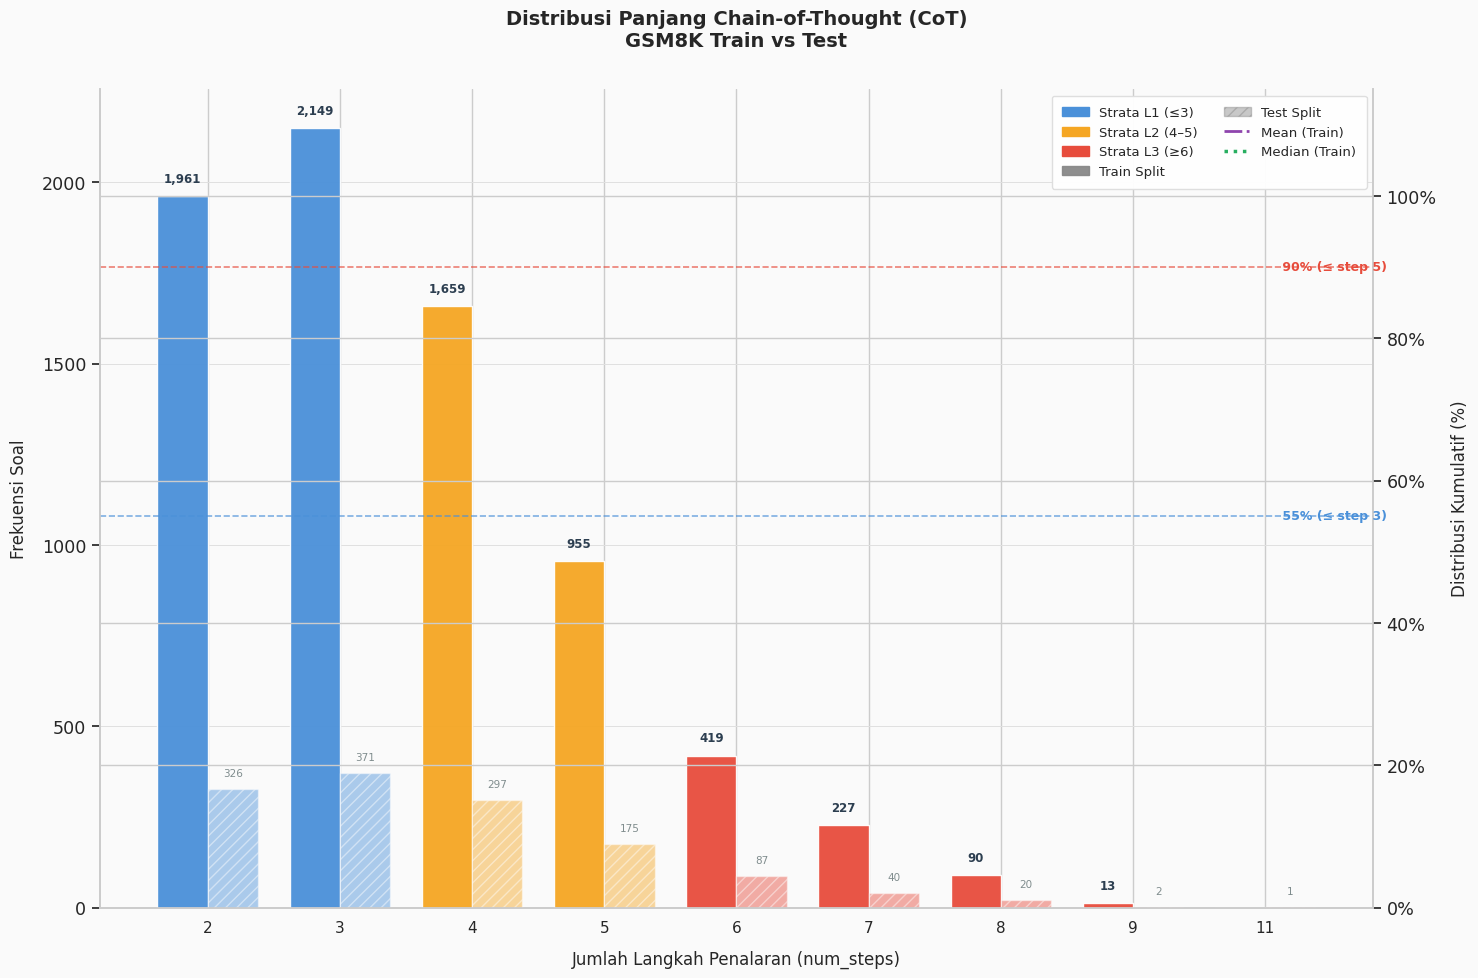

In [ ]:
colors_bar = ["#4A90D9" if s <= 3 else "#F5A623" if s <= 5 else "#E74C3C" for s in all_steps]
width = 0.38

fig, ax1 = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('#FAFAFA')
ax1.set_facecolor('#FAFAFA')

bars_train = ax1.bar(x - width/2, counts_train, width,
                     color=colors_bar, edgecolor="white", linewidth=1,
                     alpha=0.95, zorder=3, label=f"Train (n={n_train:,})")
bars_test  = ax1.bar(x + width/2, counts_test, width,
                     color=colors_bar, edgecolor="white", linewidth=1,
                     alpha=0.45, hatch="///", zorder=3, label=f"Test (n={n_test:,})")

for bar, cnt in zip(bars_train, counts_train):
    if cnt > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{cnt:,}", ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#2C3E50")
for bar, cnt in zip(bars_test, counts_test):
    if cnt > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{cnt}", ha="center", va="bottom", fontsize=7.5, color="#7F8C8D")

ax2 = ax1.twinx()

ax2.axhline(y=55.0, color="#4A90D9", linestyle="--", linewidth=1.2, alpha=0.7)
ax2.axhline(y=90.0, color="#E74C3C", linestyle="--", linewidth=1.2, alpha=0.7)
ax2.text(x[-1] + 0.1, 55.0, " 55% (≤ step 3)", fontsize=9, color="#4A90D9", va="center", fontweight="bold")
ax2.text(x[-1] + 0.1, 90.0, " 90% (≤ step 5)", fontsize=9, color="#E74C3C", va="center", fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels([f"{s}" for s in all_steps], fontsize=11)
ax1.set_xlabel("Jumlah Langkah Penalaran (num_steps)", fontsize=12, labelpad=10)
ax1.set_ylabel("Frekuensi Soal", fontsize=12, labelpad=10)
ax2.set_ylabel("Distribusi Kumulatif (%)", fontsize=12, labelpad=10)

ax2.set_ylim(0, 115)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{int(val)}%"))

ax1.set_title(
    "Distribusi Panjang Chain-of-Thought (CoT)\nGSM8K Train vs Test\n",
    fontsize=14, fontweight="bold", pad=15
)

ax1.grid(axis="y", color="#E0E0E0", linestyle="-", linewidth=0.7, zorder=0)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

strata_patches = [
    mpatches.Patch(color="#4A90D9", label="Strata L1 (≤3)"),
    mpatches.Patch(color="#F5A623", label="Strata L2 (4–5)"),
    mpatches.Patch(color="#E74C3C", label="Strata L3 (≥6)"),
    mpatches.Patch(color="#888888", alpha=0.95, label=f"Train Split"),
    mpatches.Patch(color="#888888", alpha=0.45, hatch="///", label=f"Test Split")
]

lines, labels = ax2.get_legend_handles_labels()
line_mean = plt.Line2D([0], [0], color="#8E44AD", linestyle="-.", linewidth=2)
line_median = plt.Line2D([0], [0], color="#27AE60", linestyle=":", linewidth=2.5)

all_handles = strata_patches + lines + [line_mean, line_median]
all_labels = [p.get_label() for p in strata_patches] + labels + ["Mean (Train)", "Median (Train)"]

ax2.legend(all_handles, all_labels, loc="upper right", fontsize=9.5,
           framealpha=0.95, edgecolor="#DDDDDD", borderpad=0.8, ncol=2)

plt.tight_layout()
plt.savefig("chart_paper_ready_gsm8k.png", dpi=300, bbox_inches="tight")
plt.show()

### **Distribution Analysis**

The frequency distribution indicates that the majority of GSM8K problems are concentrated in the lower-complexity category (**L1: ≤ 3 reasoning steps**), accounting for approximately **55%** of the total dataset. The distribution is centered around a median value of **3 reasoning steps**, suggesting that most problems require relatively short reasoning chains.

The intermediate-complexity category (**L2: 4–5 reasoning steps**) represents the next largest portion of the dataset, bringing the cumulative distribution to approximately **90%** of all samples. The remaining **10%** forms a long-tail distribution consisting of the most challenging problems (**L3: ≥ 6 reasoning steps**).

Furthermore, the cumulative distribution curves for the training and test splits closely overlap across all strata. This strong alignment indicates that the evaluation set preserves the original complexity distribution of the dataset, providing evidence that the sampling process is both **representative** and **statistically consistent** with the underlying GSM8K population.

#### Key Observations

- **L1 (≤ 3 steps):** Approximately 55% of the dataset, representing the majority of problems.
- **L2 (4–5 steps):** Covers most of the remaining samples, increasing cumulative coverage to roughly 90%.
- **L3 (≥ 6 steps):** Represents the long-tail portion of the dataset and contains the most complex reasoning tasks.
- **Train vs. Test Distribution:** Nearly identical cumulative trends indicate a well-balanced and representative evaluation sample.

In [ ]:
def assign_stratum(num_steps: int) -> str:

    if num_steps <= 3:
        return "L1"
    elif num_steps <= 5:
        return "L2"
    else:
        return "L3"

df_train_pool["stratum"] = df_train_pool["num_steps"].apply(assign_stratum)
df_test_pool["stratum"]  = df_test_pool["num_steps"].apply(assign_stratum)

## **Section 4 — Create Test Set**

Test set diambil dari split resmi GSM8K (`test`, n=1.319) yang **tidak digunakan
dalam proses pelatihan apapun**.

Terdapat dua versi test set yang dibuat:

1. **English** — digunakan pada eksperimen awal (baseline sebelum fine-tuning)
   dan evaluasi akhir untuk mengukur kemampuan penalaran matematis murni.
2. **Indonesian** — digunakan untuk mengukur domain shift dan hasil fine-tuning
   pada bahasa target.

**Strategi sampling: Fixed Quota Stratified (100/100/100)**

Berbeda dengan proportional sampling yang mengikuti distribusi asli (L3 hanya
~30 soal dari 300), fixed quota dipilih untuk memastikan setiap strata memiliki
sampel yang cukup untuk evaluasi yang statistically meaningful.

> **Justifikasi:** Dziri et al. (2023) membuktikan bahwa performa model menurun
> secara eksponensial seiring jumlah langkah — sehingga perbedaan performa
> antar strata justru menjadi fokus evaluasi yang paling kritis. Evaluasi yang
> adil per strata membutuhkan representasi yang setara, bukan proporsional.

**Output format:**
```json
{
  "question": "Natalia sold clips to 48 of her friends...",
  "full_answer": "Natalia sold 48/2 = <<48/2=24>>24 ...\n#### 72",
  "answer": "72",
  "num_steps": 3,
  "stratum": "L1"
}
```

In [ ]:
df_test_full = df_test_pool.copy().reset_index(drop=True)

print(f"\nTest set (FULL): {len(df_test_full)} soal")
print(df_test_full["stratum"].value_counts())


Test set (FULL): 1319 soal
stratum
L1    697
L2    472
L3    150
Name: count, dtype: int64


In [ ]:
test_english_list = []
for _, row in df_test_full.iterrows():
    test_english_list.append({
        "question"         : row["question"],
        "full_answer"      : row["full_answer"],
        "answer"           : row["extracted_answer"],
        "num_steps"        : int(row["num_steps"]),
        "stratum"          : row["stratum"],
    })

In [ ]:
with open(test_path / "test_gsm8k_english.json", "w", encoding="utf-8") as f:
    json.dump(test_english_list, f, ensure_ascii=False, indent=2)

## **Section 5 — SFT Dataset (KD CoT)**

**Complete pipeline:**
1. Take 1,500 problems from the **train split**
2. Generate English CoT via teacher model
3. Translate problems + CoT to Indonesian
4. Save as SFT dataset

### Teacher Model Selection

| Option | Model | Access Method | Cost |
|---|---|---|---|
| **Recommended** | `Qwen2.5-7B-Instruct` | Unsloth | Free |
| Alternative | `gpt-4o-mini` | OpenAI API | ~$0.01/1K problems |

> 💡 **Why 3–5 steps?** Small 1.5B models struggle to mimic excessively long CoT chains. Shorter CoT has been proven more effective for small student models.

### SFT Dataset Output Format
```json
[
  {
    "id": 0,
    "question": "Ani has 5 apples...",
    "solution": "Step 1: Ani starts with 5 apples.\nStep 2: ...\nAnswer: 3",
    "answer": "3"
  }
]
```


## Utils

In [ ]:
def normalize_number(text: str) -> str:
    """Menormalkan jawaban numerik agar mudah dibandingkan.

    Fungsi menghapus koma dan whitespace, lalu mengubah angka desimal yang
    sebenarnya bulat menjadi format integer. Jika nilai bukan angka valid,
    teks dikembalikan setelah dibersihkan.

    Args:
        text: Jawaban yang akan dinormalisasi.

    Returns:
        String jawaban yang sudah dinormalisasi, atau None jika input None.

    Examples:
        >>> normalize_number("1,250")
        "1250"
        >>> normalize_number("42.0")
        "42"
        >>> normalize_number("-3.5")
        "-3.5"
    """
    if text is None:
        return None

    text = str(text).replace(",", "").strip()

    try:
        number = float(text)

        # Menyamakan "42.0" dengan "42".
        if number.is_integer():
            return str(int(number))

        return str(number)

    except (TypeError, ValueError):
        return text


def is_correct(predicted: str, ground_truth: str) -> bool:
    """Membandingkan prediksi dan ground truth setelah normalisasi.

    Args:
        predicted: Jawaban hasil ekstraksi dari output model.
        ground_truth: Jawaban referensi dari dataset.

    Returns:
        True jika nilai prediksi sama dengan ground truth setelah normalisasi.
        False jika salah satu jawaban tidak tersedia atau nilainya berbeda.
    """
    if predicted is None or ground_truth is None:
        return False

    return normalize_number(predicted) == normalize_number(ground_truth)


def extract_boxed_answers(text: str) -> list:
    """Mengekstrak seluruh isi \\boxed{...} dari output model.

    Fungsi memakai parser kurung kurawal agar dapat membaca isi boxed yang
    memiliki nested braces, misalnya ``\\boxed{\\frac{3}{4}}``. Semua boxed
    yang lengkap dikembalikan berdasarkan urutan kemunculannya dari kiri ke
    kanan.

    Args:
        text: Output mentah model yang mungkin memuat satu atau beberapa
            ``\\boxed{...}``.

    Returns:
        List string isi setiap boxed. Mengembalikan list kosong jika tidak ada
        boxed yang valid.

    Examples:
        >>> extract_boxed_answers(
        ...     r"Langkah awal: \\boxed{4}. Hasil akhir: \\boxed{12}"
        ... )
        ["4", "12"]

        >>> extract_boxed_answers(r"Hasil: \\boxed{\\frac{3}{4}}")
        ["\\frac{3}{4}"]
    """
    if text is None or not str(text).strip():
        return []

    text = str(text)
    marker = r"\boxed{"
    answers = []
    i = 0

    while i < len(text):
        # Mencari kemunculan \boxed{ berikutnya.
        start = text.find(marker, i)

        if start == -1:
            break

        # Mulai membaca tepat setelah kurung kurawal pembuka.
        cursor = start + len(marker)
        depth = 1
        content = []

        # Membaca karakter sampai kurung kurawal terluar tertutup.
        while cursor < len(text) and depth > 0:
            char = text[cursor]

            if char == "{":
                depth += 1
            elif char == "}":
                depth -= 1

            # Tidak memasukkan "}" penutup dari wrapper \boxed{}.
            if depth > 0:
                content.append(char)

            cursor += 1

        # Menyimpan hanya \boxed{} yang memiliki kurung penutup lengkap.
        if depth == 0:
            answers.append("".join(content).strip())

        # Lanjutkan pencarian setelah boxed yang selesai diproses.
        i = cursor

    return answers


def parse_answer_qwen_math(text: str) -> str:
    """Mengekstrak jawaban akhir numerik dari output model matematika.

    Prioritas ekstraksi:
    1. Angka dari isi ``\\boxed{...}`` terakhir.
    2. Angka setelah tanda sama dengan pada akhir output.
    3. Angka terakhir di seluruh output sebagai fallback.

    Format ``JAWABAN:`` tidak dipakai karena pipeline SFT telah
    distandardkan agar jawaban akhir menggunakan ``\\boxed{...}``.

    Args:
        text: Output mentah model, termasuk reasoning dan jawaban final.

    Returns:
        String angka hasil ekstraksi, atau None jika jawaban numerik tidak
        ditemukan.

    Examples:
        >>> parse_answer_qwen_math(r"2 + 3 = 5. \\boxed{5}")
        "5"

        >>> parse_answer_qwen_math(
        ...     r"Nilai antara \\boxed{4}. Jawaban akhir \\boxed{12}"
        ... )
        "12"

        >>> parse_answer_qwen_math("Maka hasil akhir = 42")
        "42"
    """
    if text is None or not str(text).strip():
        return None

    text = str(text)

    # Membaca seluruh boxed dari akhir karena boxed terakhir paling mungkin
    # merupakan jawaban final jika reasoning mengandung boxed sebelumnya.
    boxed_answers = extract_boxed_answers(text)

    for boxed_content in reversed(boxed_answers):
        # Mendukung angka negatif, angka berkoma, dan angka desimal.
        match = re.search(
            r"-?[\d,]+(?:\.\d+)?",
            boxed_content,
        )

        if match:
            return match.group(0).replace(",", "").strip()

    # Jika tidak ada boxed numerik, cari pola akhir seperti "= 42".
    match = re.search(
        r"=\s*(-?[\d,]+(?:\.\d+)?)\s*[.!]?\s*$",
        text.strip(),
    )

    if match:
        return match.group(1).replace(",", "").strip()

    # Fallback terakhir jika model tidak memakai boxed maupun "=" di akhir.
    numbers = re.findall(
        r"-?[\d,]+(?:\.\d+)?",
        text,
    )

    if numbers:
        return numbers[-1].replace(",", "").strip()

    return None


def convert_to_standard_format(cot: str, answer: str) -> str:
    """Memastikan target CoT mempunyai jawaban akhir dengan format \\boxed{}.

    Jika CoT sumber telah memiliki ``\\boxed{...}``, fungsi mempertahankannya
    apa adanya. Tidak ada penghapusan boxed, penggantian boxed, maupun
    penambahan boxed kedua.

    Jika CoT belum memiliki boxed, jawaban ground truth dari ``answer``
    ditambahkan sebagai boxed final di akhir teks.

    Args:
        cot: Teks chain-of-thought atau solusi sumber dataset.
        answer: Jawaban ground truth. Hanya digunakan jika ``cot`` belum
            memiliki ``\\boxed{...}``.

    Returns:
        String CoT yang memiliki setidaknya satu jawaban dalam format
        ``\\boxed{...}``.

    Examples:
        >>> convert_to_standard_format(
        ...     r"2 + 3 = 5. \\boxed{5}",
        ...     "5",
        ... )
        '2 + 3 = 5. \\boxed{5}'

        >>> convert_to_standard_format(
        ...     "2 + 3 = 5.",
        ...     "5",
        ... )
        '2 + 3 = 5.\\n\\n\\\\boxed{5}'
    """
    # Memastikan input dapat diproses sebagai string dan membersihkan whitespace.
    clean_cot = "" if cot is None else str(cot).strip()
    clean_answer = "" if answer is None else str(answer).strip()

    # Mempertahankan sumber solusi bila sudah memiliki jawaban boxed.
    if r"\boxed{" in clean_cot:
        return clean_cot

    # Menambahkan jawaban boxed hanya jika solusi belum memilikinya.
    if clean_cot:
        return f"{clean_cot}\n\n\\boxed{{{clean_answer}}}"

    # Jika reasoning kosong, jawaban ground truth tetap menjadi target assistant.
    return f"\\boxed{{{clean_answer}}}"

### Qwen2.5-Math-7B-Instruct

In [ ]:
model_qwen, tokenizer_qwen = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-Math-7B-Instruct",
    max_seq_length=4096,
    dtype=torch.bfloat16,
    load_in_4bit=False,
)

FastLanguageModel.for_inference(model_qwen)
tokenizer_qwen.padding_side = "left"

==((====))==  Unsloth 2026.7.4: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [ ]:
SYSTEM_PROMPT_QWEN = "Please reason step by step, and put your final answer within \\boxed{}."

def generate_cot_batch_qwen(questions: list, batch_size: int = 32) -> list:
    all_results = []
    total_batches = (len(questions) + batch_size - 1) // batch_size

    for i in tqdm(range(0, len(questions), batch_size), total=total_batches, desc="Generating CoT"):
        batch_questions = questions[i:i+batch_size]
        batch_texts = [
            tokenizer_qwen.apply_chat_template(
                [{"role": "system", "content": SYSTEM_PROMPT_QWEN},
                 {"role": "user",   "content": q}],
                tokenize=False,
                add_generation_prompt=True
            )
            for q in batch_questions
        ]

        inputs = tokenizer_qwen(
            batch_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=256
        ).to(model_qwen.device)

        with torch.no_grad():
            outputs = model_qwen.generate(
                **inputs,
                max_new_tokens=1024,
                do_sample=False,
                temperature=None,
                top_p=None,
                pad_token_id=tokenizer_qwen.pad_token_id,
                eos_token_id=tokenizer_qwen.eos_token_id,
                use_cache=True,
            )

        for output in outputs:
            generated = output[inputs.input_ids.shape[1]:]
            decoded   = tokenizer_qwen.decode(generated, skip_special_tokens=True).strip()
            all_results.append(decoded)

        del inputs, outputs
        torch.cuda.empty_cache()

    return all_results

## SFT Candidate Sampling (Stratified Sampling)

In [ ]:
df_candidates, _ = train_test_split(
    df_train_pool,
    train_size=4000,
    stratify=df_train_pool["stratum"],
    random_state=42
)

df_candidates = df_candidates.reset_index(drop=True)

print(f"Total candidates: {len(df_candidates)}")
print(df_candidates["stratum"].value_counts())

Total candidates: 4000
stratum
L1    2200
L2    1399
L3     401
Name: count, dtype: int64


## Generate COT

In [ ]:
all_questions = df_train_pool["question"].tolist()
cot_outputs = generate_cot_batch_qwen(all_questions, batch_size=32)

assert len(cot_outputs) == len(all_questions), (
    f"Mismatch: {len(cot_outputs)} outputs vs {len(all_questions)} questions."
)

Generating CoT:   1%|          | 2/234 [05:29<10:37:36, 164.90s/it]


KeyboardInterrupt: 

In [ ]:
skipped_qwen = 0
skipped_by_stratum = {}
sft_data_qwen = {}

for idx, cot_output in enumerate(tqdm(cot_outputs, total=len(cot_outputs), desc="Verifying")):
    ground_truth  = df_train_pool.loc[idx, "extracted_answer"]
    question_text = df_train_pool.loc[idx, "question"]
    strata_label  = df_train_pool.loc[idx, "stratum"]

    predicted = parse_answer_qwen_math(cot_output)

    if is_correct(predicted, ground_truth):
        sft_data_qwen[idx] = {
            "question": question_text,
            "solution": convert_to_standard_format(cot_output, ground_truth),
            "answer"  : ground_truth,
            "stratum" : strata_label,
        }
    else:
        skipped_qwen += 1
        skipped_by_stratum[strata_label] = skipped_by_stratum.get(strata_label, 0) + 1


Verifying: 100%|██████████| 4000/4000 [00:00<00:00, 4333.67it/s]


In [ ]:
total_candidates = len(all_questions)
total_passed     = len(sft_data_qwen)
pass_rate        = total_passed / total_candidates * 100

print(f"\n{'='*50}")
print(f"Total kandidat     : {total_candidates}")
print(f"Lolos verifikasi   : {total_passed} ({pass_rate:.1f}%)")
print(f"Diskip (salah/None): {skipped_qwen} ({100 - pass_rate:.1f}%)")
print(f"{'='*50}")
print("\nDistribusi Lolos per Stratum:")
print(pd.Series([v["stratum"] for v in sft_data_qwen.values()]).value_counts())
print("\nDistribusi Gagal per Stratum:")
print(pd.Series(skipped_by_stratum).sort_index() if skipped_by_stratum else "Tidak ada.")


Total kandidat     : 4000
Lolos verifikasi   : 3825 (95.6%)
Diskip (salah/None): 175 (4.4%)

Distribusi Lolos per Stratum:
L1    2141
L2    1326
L3     358
Name: count, dtype: int64

Distribusi Gagal per Stratum:
L1    59
L2    73
L3    43
dtype: int64


In [ ]:
sft_list = list(sft_data_qwen.values())
print("\nSpot-check 3 sampel acak:")
for i, item in enumerate(random.sample(sft_list, min(3, len(sft_list)))):
    print(f"\n--- Sampel {i+1} ---")
    print(f"Stratum  : {item['stratum']}")
    print(f"Question : {item['question'][:100]}...")
    print(f"Answer   : {item['answer']}")
    print(f"Solution (akhir):\n...{item['solution'][-300:]}")


Spot-check 3 sampel acak:

--- Sampel 1 ---
Stratum  : L1
Question : A desert has 3/5 fewer palm trees than a nearby forest, which has 5000 palm trees. How many palm tre...
Answer   : 7000
Solution (akhir):
...umber of palm trees in the forest to the number of palm trees in the desert to find the total number of palm trees in both places:

\text{Total number of palm trees} = 5000 + 2000 = 7000


Thus, the total number of palm trees in both the desert and the forest combined is 7000.

JAWABAN: \boxed{7000}

--- Sampel 2 ---
Stratum  : L1
Question : Hazel walked 2 kilometers in the first hour. If she walked twice as far in the second hour, how far ...
Answer   : 6
Solution (akhir):
...hour, she walked 2 \times 2 = 4 kilometers in the second hour.

Next, we add the distances from both hours to find the total distance walked:
2 \text{ kilometers} + 4 \text{ kilometers} = 6 \text{ kilometers}

Therefore, the total distance Hazel walked in 2 hours is 6 kilometers.

JAWABAN: \boxed{6}

--- S

### Save SFT Dataset

In [ ]:
with open(sft_path / "sft_qwen7B_english.json", "w", encoding="utf-8") as f:
    json.dump(sft_list, f, ensure_ascii=False, indent=2)

### SLERP t-Search Validation Set Preparation

In [ ]:
RANDOM_STATE = 42
N_PER_STRATUM = 70

In [ ]:
with open(sft_path / "sft_dataset_new_format.json", "r", encoding="utf-8") as f:
    sft_list = json.load(f)

used_questions = set(item["question"].strip() for item in sft_list)

#### Exclude questions already used in SFT

In [ ]:
df_train_pool["question"] = df_train_pool["question"].str.strip()
df_available_pool = df_train_pool[~df_train_pool["question"].isin(used_questions)].reset_index(drop=True)

#### Stratified sampling for t-search validation set

In [ ]:
val_parts = []
for stratum in ["L1", "L2", "L3"]:
    pool_stratum = df_available_pool[df_available_pool["stratum"] == stratum]
    n_sample = min(N_PER_STRATUM, len(pool_stratum))
    val_parts.append(pool_stratum.sample(n=n_sample, random_state=RANDOM_STATE))

In [ ]:
df_val_tsearch = pd.concat(val_parts, ignore_index=True)
df_val_tsearch = df_val_tsearch.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

#### Validation: no overlap with SFT or test set

In [ ]:
val_questions = set(df_val_tsearch["question"].str.strip())
assert not (val_questions & used_questions)
assert not (val_questions & set(df_test_pool["question"].str.strip()))

In [ ]:
df_val_tsearch.to_json(
    slerp_path / "val_tsearch_pool.json", orient="records", force_ascii=False, indent=2
)

In [ ]:
df_val_tsearch.to_excel(slerp_path / "val_tsearch_pool.xlsx", index=False)

In [ ]:
for i, start in enumerate(range(0, len(df_val_tsearch), N_PER_STRATUM)):
    df_chunk = df_val_tsearch.loc[start : start + N_PER_STRATUM - 1, ["question"]]

    df_chunk.to_json(
        slerp_path / f"val_tsearch_question_only_pool_{i+1}.json",
        orient="records",
        force_ascii=False,
        indent=2,
    )

## **Section 5 - Translate Problems to Indonesian**

In [ ]:
client = OpenAI(api_key=OPENAI_API_KEY)

translate_question_prompt = """
You are a professional translator for school-level mathematics.

Translate the following math word problem from English to Indonesian.

Rules:
1. Preserve all numbers exactly as written.
2. Do not change any mathematical expressions, equations, units, or quantities.
3. Preserve all quantitative relationships exactly, including more/less, half, double, times, before/after, and comparison direction.
4. Use formal Indonesian in textbook style (bahasa Indonesia baku), not conversational language.
5. Keep person names as-is. If the same person is referred to by multiple names, use the first name consistently.
6. Do not solve the problem.
7. Output only the translated problem.

Terminology preferences:
- quotient = hasil bagi
- remainder = sisa
- profit = keuntungan
- loss = kerugian
- twice as many = dua kali lebih banyak
- half of = setengah dari

Example:
English: Tom has 3 more apples than Jerry. Jerry has 5 apples. How many apples does Tom have?
Indonesian: Tom memiliki 3 apel lebih banyak daripada Jerry. Jerry memiliki 5 apel. Berapa banyak apel yang dimiliki Tom?

English: {question}
Indonesian:
"""

In [ ]:
translate_cot_prompt = """
You are an expert mathematical translator specializing in Large Language Model reasoning datasets.
Translate the following mathematical Chain-of-Thought (CoT) reasoning steps from English to formal Indonesian.

Rules:
1. Preserve all numbers, arithmetic operations, and mathematical symbols exactly as written.

2. Keep all LaTeX block equations (enclosed in \\[ \\] or \\( \\)) structurally unaltered,
   EXCEPT for \\text{} labels inside them — translate the content of \\text{} labels into
   formal Indonesian as well.
   Example: \\text{Total volume} → \\text{Total volume} becomes \\text{Volume total},
            \\text{Remaining amount} → \\text{Jumlah tersisa},
            \\text{Cost per ticket} → \\text{Biaya per tiket}.
  - Also translate \text{} unit labels (e.g., \text{hours} → \text{jam}, \text{gallons} → \text{galon},
  \text{cents} → \text{sen}, \text{dollars} → \text{dolar}, \text{sets} → \text{kelompok})

3. Translate ALL natural language text outside LaTeX blocks into formal Indonesian
   (bahasa Indonesia baku)

4. Use consistent terminology throughout a single item. If a noun is translated one way
   in the question, use the same translation in the solution.
   Example: if "mason jar" → "stoples mason" in the question, use "stoples mason"
   consistently in the solution — not "toples".

5. For food items, branded terms, or proper nouns with no established Indonesian equivalent
   (e.g., "mini-cupcakes", "donut holes"), keep the original English term as-is.

6. Maintain the exact logical flow and quantitative relationships.

7. Do not output the final answer format line starting with #### as it is added automatically.
"""

In [ ]:
def translate_to_indonesian(question: str, prompt: str) -> str:
    response = client.chat.completions.create(
        model="gpt-5.4-mini",
        temperature=0.0,
        seed=42,
        messages=[
            {
                "role": "system",
                "content": prompt
            },
            {
                "role": "user",
                "content": question
            }
        ]
    )
    return response.choices[0].message.content

## Translate Test Data

In [ ]:
df_test_sample_dict = df_test_sample.to_dict(orient='index')

In [ ]:
translated_test_data = {}

for index, data in tqdm(df_test_sample_dict.items(), total=len(df_test_sample_dict)):
    translated_test_data[index] = {
        "question": translate_to_indonesian(data["question"], translate_question_prompt),
        "chain-of-thought": data["full_answer"],
        "extracted_answer": data["extracted_answer"],
        "num_steps": data['num_steps'],
        "strata": data['stratum']
    }

100%|██████████| 300/300 [06:21<00:00,  1.27s/it]


### Save Test Data to Json File

In [ ]:
with open(test_path / "indonesian_test_set.json", "w", encoding="utf-8") as f:
    json.dump(translated_test_data, f, ensure_ascii=False, indent=2)

with open(test_path / "english_test_set.json", "w", encoding="utf-8") as f:
    json.dump(df_test_sample_dict, f, ensure_ascii=False, indent=2)

### Translate SFT Dataset

In [ ]:
json_file = "translated_sft_data.json"
csv_file = "translated_sft_data.csv"

if os.path.exists(json_file):
    with open(json_file, 'r', encoding='utf-8') as f:
        translated_sft_data = json.load(f)
    print(f"Melanjutkan progress: {len(translated_sft_data)} data sudah diterjemahkan.")
else:
    translated_sft_data = {}

for index, data in tqdm(sft_data_qwen.items(), total=len(sft_data_qwen)):
    if str(index) in translated_sft_data or index in translated_sft_data:
        continue

    try:
        translated_sft_data[index] = {
            "question": translate_to_indonesian(data["question"], translate_question_prompt),
            "solution": translate_to_indonesian(data["solution"], translate_cot_prompt),
            "answer": data['answer'],
            "strata": data['strata']
        }

        with open(json_file, 'w', encoding='utf-8') as f:
            json.dump(translated_sft_data, f, ensure_ascii=False, indent=4)

        pd.DataFrame.from_dict(translated_sft_data, orient='index').to_csv(csv_file)

    except Exception as e:
        print(f"\n[ERROR] Terjadi kesalahan pada index {index}: {e}")
        break

if len(translated_sft_data) == len(sft_data_qwen):
    df_final = pd.DataFrame.from_dict(translated_sft_data, orient='index')
    df_final.to_excel("translated_sft_data_final.xlsx")

100%|██████████| 1880/1880 [2:07:58<00:00,  4.08s/it]


In [ ]:
df_final = pd.read_excel("translated_sft_data_final.xlsx")
translated_sft_data = df_final.to_dict(orient='index')

In [ ]:
def format_solutions(dataset_dict):
    formatted_data = {}

    for key, item in dataset_dict.items():
        solution = item.get('solution', '')
        answer = item.get('answer', '')

        clean_answer = str(answer).strip()

        if not re.search(r'\\boxed\{', solution):
            formatted_solution = f"{solution}\n\nJAWABAN: \\boxed{{{clean_answer}}}"
        else:
            formatted_solution = solution

        formatted_item = item.copy()
        formatted_item['solution'] = formatted_solution
        formatted_data[key] = formatted_item

    return formatted_data

In [ ]:
formatted_sft_data = format_solutions(translated_sft_data)

### Save Translated Dataset

## Section 5 — Create RL Dataset

The RL dataset format **only requires the problem + final answer** — no CoT needed.
The model will generate its own CoT during rollout in the GRPO process.

**Problem source:** Take from the train split, **ensure no overlap with the SFT pool**.

**Count:** 1,000–2,000 problems (before filtering). After pass rate filtering later, the effective count will be around 300–800 problems.

### RL Dataset Output Format
```json
[
  {
    "id": 0,
    "question": "Ani has 5 apples...",
    "answer": "3"
  }
]
```

> ⚠️ **Pass rate filtering (0.1–0.8) is performed later after SFT is complete**, not now. For now, simply save all problems first.